# Restaurant Branch Performance - Exploratory Data Analysis


In [12]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import pandas as pd
# Load the dataset

df = pd.read_csv("/content/Day13_Restaurant_Branch_Performance_Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [14]:
# 3. Display Dataset
display(df.head())
display(df.tail())

,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
345,ST0346,2026-02-08,Sunday,February,Mumbai,West,Express,10,7389.17,202,...,56852.25,18863.88,43733.92,13118.33,27.2,4.63,28.9,64.6,Rain,NaN
346,ST0347,2026-06-05,Friday,June,Mumbai,West,Premium,12,8398.13,274,...,138198.35,50914.04,75370.62,62827.73,35.4,4.32,22.7,57.9,Rain,NaN
347,ST0348,2026-03-13,Friday,March,Bengaluru,South,Standard,16,2876.93,196,...,62974.97,23946.23,51377.97,11597.00,22.5,4.51,32.3,63.4,Clear,Combo Deal
348,ST0349,2026-03-10,Tuesday,March,Jaipur,North,Standard,9,4731.74,200,...,78451.05,26050.73,47400.29,31050.76,28.3,4.51,24.7,58.6,Clear,Loyalty Offer
349,ST0350,2026-02-03,Tuesday,February,Pune,West,Standard,16,7004.28,225,...,86122.21,28144.81,54734.11,31388.10,22.7,4.30,32.0,83.9,Clear,NaN


In [15]:
# 4-6. Basic Info, Descriptive Stats and Missing Values
print("Rows and Columns:", df.shape)
display(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

Rows and Columns: (350, 22)


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000



Missing Values:
 Record_ID             0
Date                  0
Day                   0
Month                 0
Branch                0
Region                0
Store_Type            0
Staff_Count           0
Marketing_Spend       0
Customers             0
Orders                0
Average_Bill          0
Revenue               0
Food_Cost             0
Operating_Cost        0
Profit                0
Avg_Delivery_Min      0
Customer_Rating       0
Temperature_C         0
Humidity_Percent      0
Weather               0
Promotion           184
dtype: int64


Average Customers: 217.37714285714284
Average Revenue: ₹ 86831.79965714287


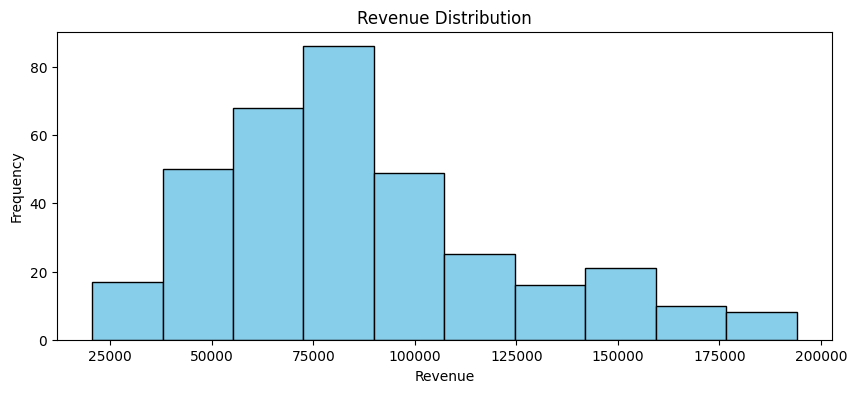

In [16]:
# 7-14. Numerical and Distribution Analysis
print("Average Customers:", df["Customers"].mean())
print("Average Revenue: ₹", df["Revenue"].mean())

plt.figure(figsize=(10, 4))
plt.hist(df["Revenue"], bins=10, color='skyblue', edgecolor='black')
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [17]:
# 15-17. Performance by Branch, Region, and Store Type
branch_summary = df.groupby("Branch").agg({"Revenue": "sum", "Profit": "sum", "Customers": "sum"}).sort_values("Revenue", ascending=False)
display(branch_summary.head())

region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
display(region_revenue)

,Revenue,Profit,Customers
Branch,,,
Srinagar,4510816.59,1575751.62,11166
Bengaluru,4173677.46,1466982.08,10465
Jaipur,4163815.60,1462545.76,10717
Kochi,4107581.66,1387297.74,10035
Hyderabad,3818610.68,1350328.01,9494


,Revenue
Region,
South,12099869.80
North,11476996.01
West,6814264.07


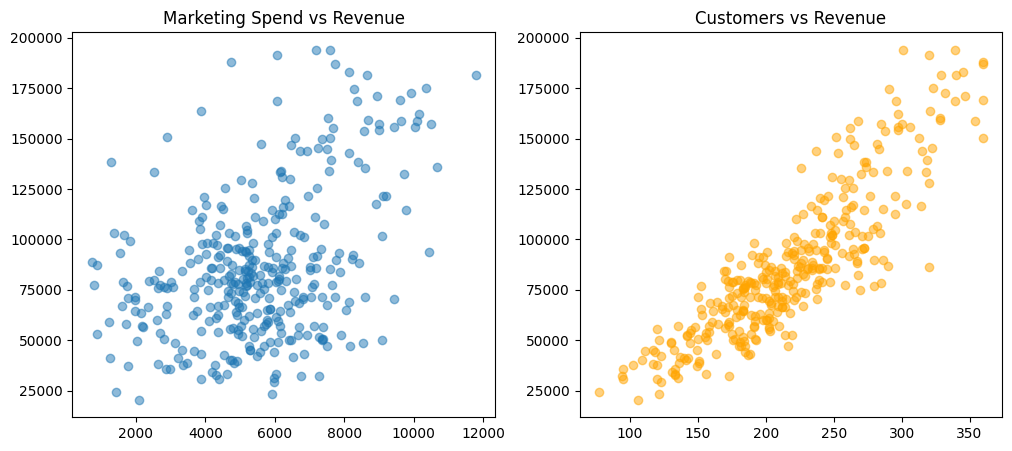

In [18]:
# 18-20. Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df["Marketing_Spend"], df["Revenue"], alpha=0.5)
axes[0].set_title("Marketing Spend vs Revenue")
axes[1].scatter(df["Customers"], df["Revenue"], color='orange', alpha=0.5)
axes[1].set_title("Customers vs Revenue")
plt.show()

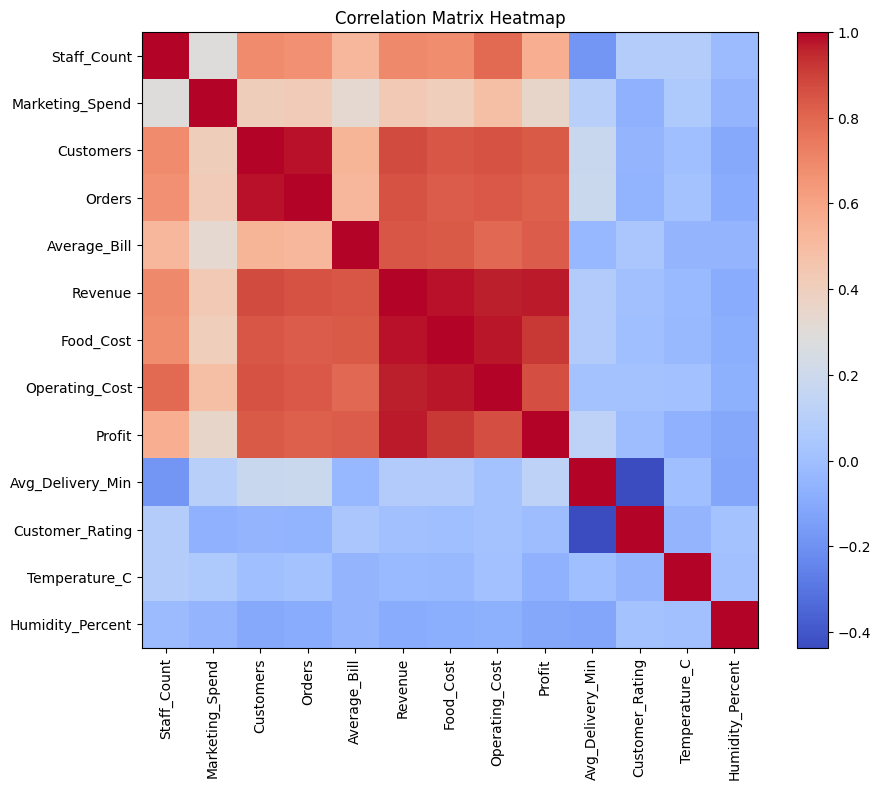

In [19]:
# 21. Correlation Heatmap
numeric_data = df.select_dtypes(include='number')
corr = numeric_data.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [20]:
# 22-24. Summary Statistics
print("Highest Revenue Record:", df.loc[df['Revenue'].idxmax(), ['Branch', 'Revenue']])
print("Overall Total Profit: ₹", round(df['Profit'].sum(), 2))

Highest Revenue Record: Branch      Srinagar
Revenue    194018.92
Name: 85, dtype: object
Overall Total Profit: ₹ 10573624.31
